In [1]:
import pandas as pd
import numpy as np
import os

from sklearn.metrics import (
    roc_auc_score, precision_score, 
    recall_score, f1_score, 
    matthews_corrcoef,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

import mlflow
import mlflow.sklearn

import warnings
import argparse
import logging
from typing import *

import matplotlib.pyplot as plt
import seaborn as sns
from namespaces import DA

/home/mai/notebooks/final_thesis/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
logging.basicConfig(level=logging.WARN)
logger = logging.getLogger(__name__)
warnings.filterwarnings("ignore")

In [3]:
os.chdir('/home/mai/notebooks/final_thesis/')
os.getcwd()

'/home/mai/notebooks/final_thesis'

In [17]:
# search for the best run
experiment_name = 'nb_priors_tuning'
metric_name = ['auc', 'mcc']

exp = mlflow.get_experiment_by_name(experiment_name)
runs = mlflow.search_runs(
    experiment_ids=[exp.experiment_id],
    order_by=[
        f"metrics.{metric_name[0]} DESC",
        # f"metrics.{metric_name[1]} DESC"
    ],
    max_results=1
)

best_run = runs.iloc[0]
best_run_id = best_run.run_id

print("Experiment ID:", exp.experiment_id)
print("Best run:", best_run_id)
print("Best metric - AUC:", best_run[f"metrics.{metric_name[0]}"], "MCC:", best_run[f"metrics.{metric_name[1]}"])

Experiment ID: 6
Best run: c777faa893fb470988d30e81f474229f
Best metric - AUC: 0.6970634880622775 MCC: 0.06652975957936119


In [5]:
# load best model
model = mlflow.sklearn.load_model(f"runs:/{best_run.run_id}/model")

In [6]:
def load_data(data_path):
    data = np.load(os.path.join(data_path, 'dgraphfin_processed.npz'))
    # train
    X_train = pd.DataFrame(data['x_train'])
    y_train = pd.DataFrame(data['y_train'])
    # val
    X_val = pd.DataFrame(data['x_val'])
    y_val = pd.DataFrame(data['y_val'])
    # test
    X_test = pd.DataFrame(data['x_test'])
    y_test = pd.DataFrame(data['y_test'])
    return X_train, X_val, X_test, y_train, y_val, y_test


def eval_metrics(actual, pred_labels, pred_probas):
    auc = roc_auc_score(actual, pred_probas)
    recall = recall_score(actual, pred_labels)
    precision = precision_score(actual, pred_labels)
    f1 = recall_score(actual, pred_labels)
    matthews_corr = matthews_corrcoef(actual, pred_labels)
    return auc, recall, precision, f1, matthews_corr

In [7]:
_, X_val, X_test, _, y_val, y_test = load_data(DA.paths.output_data_ml)

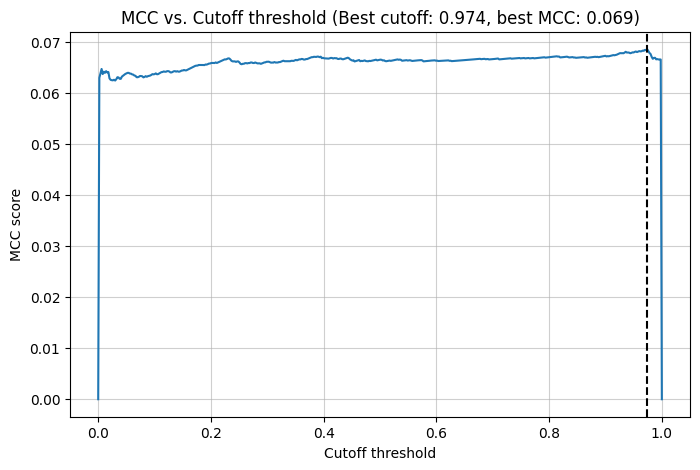

In [8]:
# cutoff selection to maximize mcc
y_prob = model.predict_proba(X_val)[:, 1]
thresholds = np.linspace(0, 1, 500)
mcc_scores = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    mcc_scores.append(matthews_corrcoef(y_val, y_pred))

best_idx = np.argmax(mcc_scores)
best_threshold = thresholds[best_idx]
best_mcc = mcc_scores[best_idx]

plt.figure(figsize=(8, 5))
plt.plot(thresholds, mcc_scores)
plt.axvline(best_threshold, ls='--', color='k')
plt.title(f"MCC vs. Cutoff threshold (Best cutoff: {best_threshold:.3f}, best MCC: {best_mcc:.3f})")
plt.xlabel("Cutoff threshold")
plt.ylabel("MCC score")
plt.grid(True, axis='both', alpha=.6)
plt.show()

In [9]:
# use selected threshold on test set
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= best_threshold).astype(int)

# eval
auc, recall, precision, f1, mcc = eval_metrics(y_test, y_pred, y_prob)

In [10]:
print(f'AUC: {auc:.4f}')
print(f'Recall: {recall:.4f}')
print(f'Precision: {precision:.4f}')
print(f'F1: {f1:.4f}')
print(f'MCC: {mcc:.4f}')

AUC: 0.7030
Recall: 0.6819
Precision: 0.0226
F1: 0.6819
MCC: 0.0697


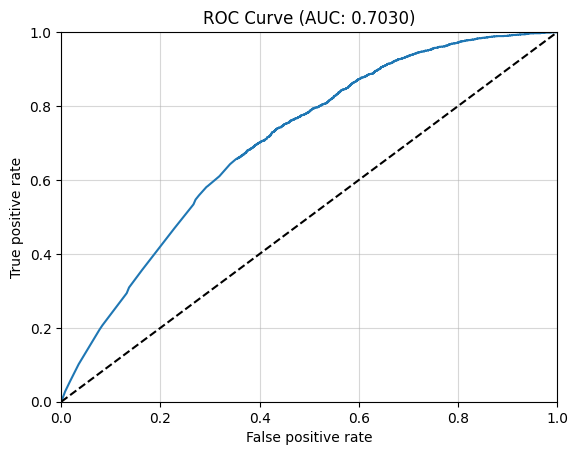

In [11]:
# examine ROC curve
fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], ls='--', color='k')
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title(f"ROC Curve (AUC: {auc:.4f})")
plt.grid(True, axis='both', alpha=0.5)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()

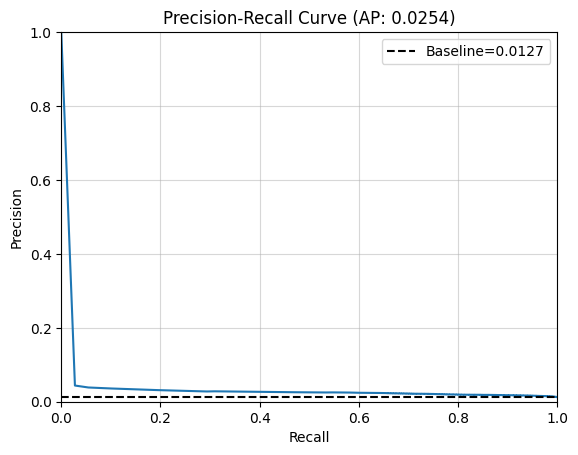

In [12]:
# examine precision recall curve
pr, rc, thresholds = precision_recall_curve(y_test, y_prob)
ap_value = average_precision_score(y_test, y_prob)
baseline = np.mean(y_test)

plt.figure()
plt.plot(rc, pr)
plt.axhline(baseline, linestyle="--", label=f"Baseline={baseline:.4f}", color='k')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (AP: {ap_value:.4f})")
plt.grid(True, axis='both', alpha=0.5)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.show()

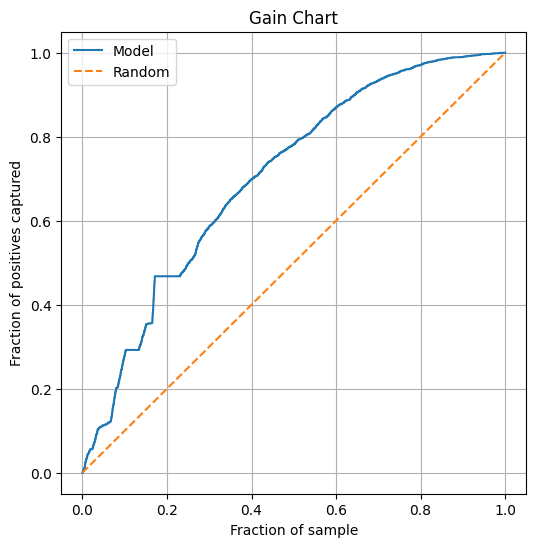

In [13]:
# examine gain and lift charts
gl = pd.DataFrame({
    'y_test': y_test.values.ravel(),
    'y_prob': y_prob
})

gl = gl.sort_values(by='y_prob', ascending=False).reset_index(drop=True)

gl['cum_positives'] = gl['y_test'].cumsum()
gl['gain'] = gl['cum_positives'] / gl['y_test'].sum()
gl['samples_frac'] = np.arange(1, len(gl)+1) / len(gl)

plt.figure(figsize=(6, 6))
plt.plot(gl["samples_frac"], gl["gain"], label="Model")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")  # random baseline
plt.xlabel("Fraction of sample")
plt.ylabel("Fraction of positives captured")
plt.title("Gain Chart")
plt.legend()
plt.grid(True)
plt.show()

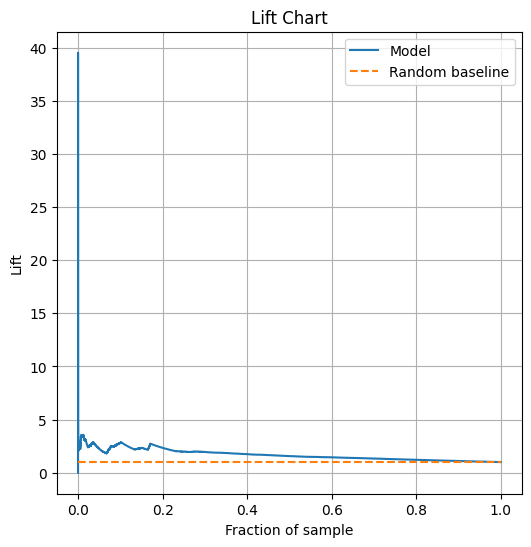

In [14]:
# examine lift chart
gl['lift'] = gl['gain'] / gl['samples_frac']

plt.figure(figsize=(6, 6))
plt.plot(gl["samples_frac"], gl["lift"], label="Model")
plt.plot([0, 1], [1, 1], linestyle="--", label="Random baseline")  # baseline lift = 1
plt.xlabel("Fraction of sample")
plt.ylabel("Lift")
plt.title("Lift Chart")
plt.legend()
plt.grid(True)
plt.show()

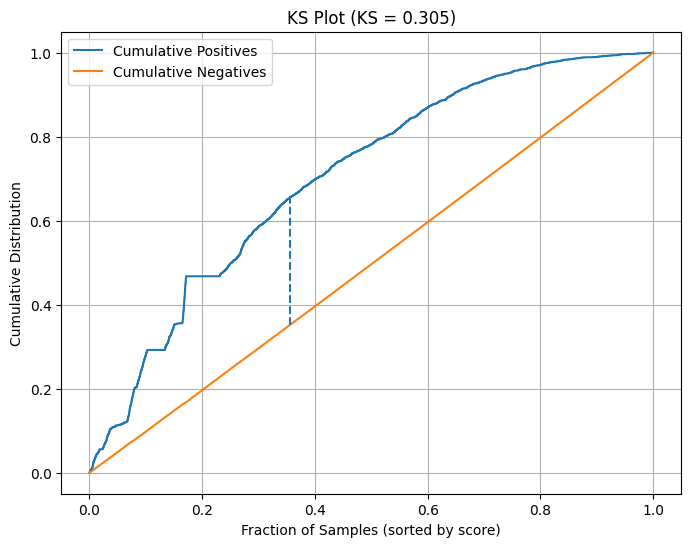

In [15]:
# KS plot
# negatives indicator
gl['neg'] = 1 - gl['y_test']

# cumulative negatives
gl['cum_negatives'] = gl['neg'].cumsum()

# normalize both cumulative curves
gl['cum_pos_rate'] = gl['cum_positives'] / gl['cum_positives'].iloc[-1]
gl['cum_neg_rate'] = gl['cum_negatives'] / gl['cum_negatives'].iloc[-1]

# KS distance
gl['ks'] = gl['cum_pos_rate'] - gl['cum_neg_rate']

ks_value = gl['ks'].abs().max()
ks_idx = gl['ks'].abs().idxmax()

plt.figure(figsize=(8,6))

plt.plot(gl['samples_frac'], gl['cum_pos_rate'], label='Cumulative Positives')
plt.plot(gl['samples_frac'], gl['cum_neg_rate'], label='Cumulative Negatives')

# KS vertical line
plt.vlines(gl.loc[ks_idx, 'samples_frac'],
           gl.loc[ks_idx, 'cum_neg_rate'],
           gl.loc[ks_idx, 'cum_pos_rate'],
           linestyles='dashed')

plt.title(f"KS Plot (KS = {ks_value:.3f})")
plt.xlabel("Fraction of Samples (sorted by score)")
plt.ylabel("Cumulative Distribution")
plt.legend()
plt.grid(True)
plt.show()